# Installs

<li>pip install mne<li>
<li>pip install pandas<li>
<li>pip install numpy<li>
<li>pip install torch<li>
<li>pip install torcheeg<li>

In [1]:

import os
import random
import time
from mne.datasets import eegbci
import mne
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from matplotlib import pyplot as plt
from sklearn import metrics
from torcheeg import transforms
from collections import Counter
from torcheeg.model_selection import KFold
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split


# DownLoading data

In [2]:
edffiles=r"C:\Users\johan\Documents\Documents\School\advanced machine learning\PROJECT\BCI"
subjects_id=np.arange(1,5)
runs_id=np.arange(4,10)
paths=eegbci.load_data(subjects=subjects_id, runs=runs_id,path=edffiles, update_path=True)
paths

c:\Users\johan\Documents\Documents\School\advanced machine learning\torcheeg-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R05.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R07.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R09.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/

# Check cuda is available


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


### Read raw data from edf

In [4]:
edffile=r'C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S003/S003R03.edf'


raw=mne.io.read_raw_edf(edffile)
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

### Print meta data: task duration, task counts, onset and channel names

In [5]:
print("duration: ",raw.annotations.duration)
print("count: ",raw.annotations.count())
print("onset:  ",raw.annotations.onset)
print("channel names: ",raw.ch_names)
raw.annotations.to_data_frame()


duration:  [4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1
 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1]
count:  {'T0': 15, 'T1': 7, 'T2': 8}
onset:   [  0.    4.2   8.3  12.5  16.6  20.8  24.9  29.1  33.2  37.4  41.5  45.7
  49.8  54.   58.1  62.3  66.4  70.6  74.7  78.9  83.   87.2  91.3  95.5
  99.6 103.8 107.9 112.1 116.2 120.4]
channel names:  ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


,onset,duration,description
0,2009-08-12 16:15:00.000,4.2,T0
1,2009-08-12 16:15:04.200,4.1,T2
2,2009-08-12 16:15:08.300,4.2,T0
3,2009-08-12 16:15:12.500,4.1,T1
4,2009-08-12 16:15:16.600,4.2,T0
5,2009-08-12 16:15:20.800,4.1,T2
6,2009-08-12 16:15:24.900,4.2,T0
7,2009-08-12 16:15:29.100,4.1,T1
8,2009-08-12 16:15:33.200,4.2,T0
9,2009-08-12 16:15:37.400,4.1,T1


### Read events meta data for each task

In [6]:
events_=mne.events_from_annotations(raw)
counter=0
for i in events_[0]:
    print(f"number is {counter +1}: ",i)
    counter +=1

number is 1:  [0 0 1]
number is 2:  [672   0   3]
number is 3:  [1328    0    1]
number is 4:  [2000    0    2]
number is 5:  [2656    0    1]
number is 6:  [3328    0    3]
number is 7:  [3984    0    1]
number is 8:  [4656    0    2]
number is 9:  [5312    0    1]
number is 10:  [5984    0    2]
number is 11:  [6640    0    1]
number is 12:  [7312    0    3]
number is 13:  [7968    0    1]
number is 14:  [8640    0    3]
number is 15:  [9296    0    1]
number is 16:  [9968    0    2]
number is 17:  [10624     0     1]
number is 18:  [11296     0     2]
number is 19:  [11952     0     1]
number is 20:  [12624     0     3]
number is 21:  [13280     0     1]
number is 22:  [13952     0     2]
number is 23:  [14608     0     1]
number is 24:  [15280     0     3]
number is 25:  [15936     0     1]
number is 26:  [16608     0     3]
number is 27:  [17264     0     1]
number is 28:  [17936     0     2]
number is 29:  [18592     0     1]
number is 30:  [19264     0     3]


### Read raw data, divide into task lengths and map task to movement number
return X matric and y labels


In [7]:
def get_X_y(path: str, movement: str )-> tuple[list,list]:
    raw_data=mne.io.read_raw_edf(path)
    durations=raw.annotations.duration
    onset=raw.annotations.onset
    events_=mne.events_from_annotations(raw_data)
    tasks={}
    X=[]
    y=[]
    counter=0
    match movement:
        case 'lr':
            tasks={1:0, 2:1, 3:2}
            
        case 'ilr':
            tasks={1:0, 2:3, 3:4}
        case 'ff':
            tasks={1:0, 2:5, 3:6}
        case 'iff':
            tasks={1:0, 2:7, 3:8}
        case _:

            raise ValueError(f"movement: {movement} is not supported. Chose either lr, ilr, ff or iff")
    
    for e,o,d in zip(events_[0],onset,durations):
        X.append(raw_data.get_data(start=int ( o * 160), stop= int (( d * 160) + ( o * 160))))
        y.append(e[2])
        counter+=1

    y=list(map(lambda x: tasks[x], y))
    return X, y



# Read edf data 
Read Edf data files for participant 1 and consolidate data from multiple files into one X data and coresponding class labels

In [65]:
edffiles=r"C:\Users\johan\Documents\Documents\School\advanced machine learning\PROJECT\BCI"
lr=[3,7,11]
ilr=[4,8,12]
ff=[5,9,13]
iff=[6,10,14]
movements=[lr,ilr,ff,iff]
mov_str=['lr','ilr','ff','iff']
X=[]
y=[]
for m,sr in zip(movements,mov_str):
    paths=eegbci.load_data(subjects=[1], runs=m,path=edffiles, update_path=True)
    for path in paths:
        Xs,ys=get_X_y(path,sr)
        X.extend(Xs)
        y.extend(ys)

len(y)

360

# Visualization
Plot raw data

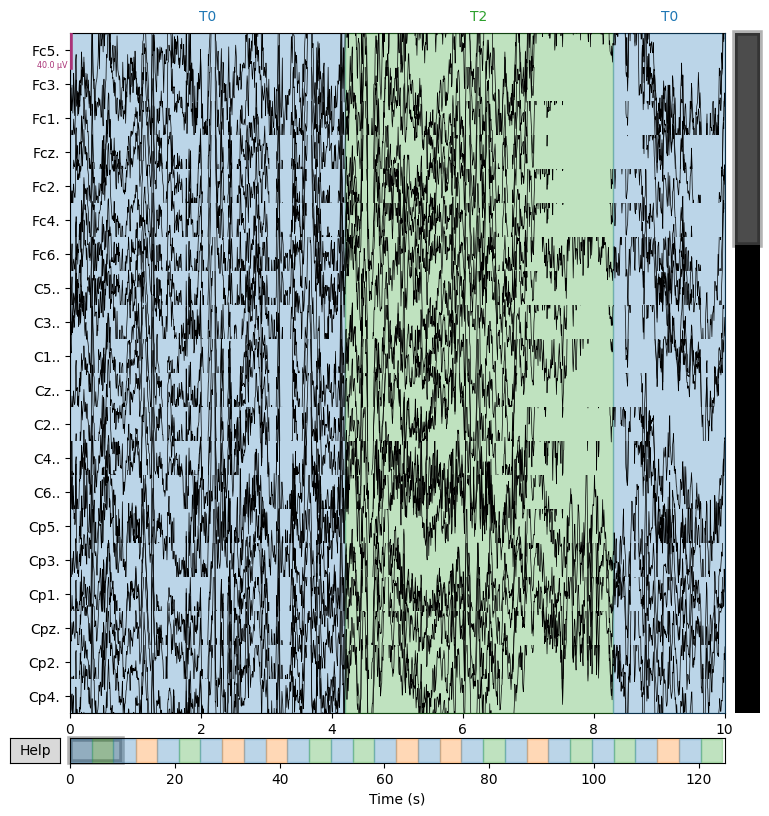

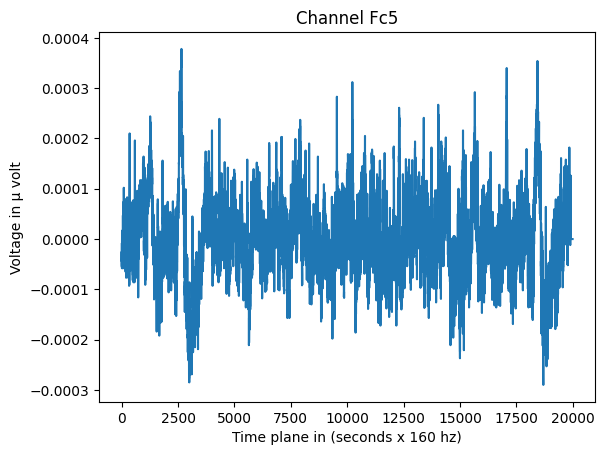

In [9]:
raw.plot(show_options=True,title="Plot of EEG signals")
first_ch=raw[0][0]
first_ch
plt.plot(first_ch[0])
plt.title("Channel Fc5")
plt.xlabel("Time plane in (seconds x 160 hz)")
plt.ylabel("Voltage in µ volt")
plt.show()


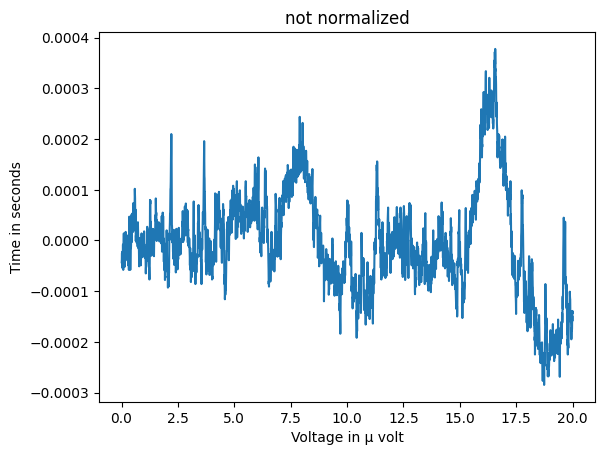

In [10]:
data=raw.get_data()
ch_1=data[0]

hs=160
n=np.arange(1, 3201)
n=n/hs # set seconds
plt.plot(n,ch_1[:3200]) # first 20 seconds = 160 X 20
plt.title("not normalized")
plt.xlabel("Voltage in µ volt")
plt.ylabel("Time in seconds")
plt.show()



# Preprocessing
## Treat unequal sizes
Add zero padding of 0.1 second time e.g. 16 time steps at the end for every non baseline segment
## Subtract mean matrix from every task segement

In [61]:

arr1=np.array([[1,1,1],[2,2,2],[3,3,3]])
arr2=np.array([[4,4,4],[5,5,5],[6,6,6]])
arr3=np.array([[7,7,7],[8,8,8],[9,9,9]])
arr=np.array([arr1,arr2,arr3])
print("Numpy Mean: ",arr.mean(axis=0))
testMean=0
counter=0
for i in range (len(arr)):
    print(f"arr[{i}]= {arr[i]}")
    testMean=testMean+arr[i]
    print(f"testMean= {testMean}")
    counter+=1
testmean=testMean/counter
print("testmean: ",testmean)
for i in range (len(arr)):
    arr[i]=arr[i]-testmean

arr



Numpy Mean:  [[4. 4. 4.]
 [5. 5. 5.]
 [6. 6. 6.]]
arr[0]= [[1 1 1]
 [2 2 2]
 [3 3 3]]
testMean= [[1 1 1]
 [2 2 2]
 [3 3 3]]
arr[1]= [[4 4 4]
 [5 5 5]
 [6 6 6]]
testMean= [[5 5 5]
 [7 7 7]
 [9 9 9]]
arr[2]= [[7 7 7]
 [8 8 8]
 [9 9 9]]
testMean= [[12 12 12]
 [15 15 15]
 [18 18 18]]
testmean:  [[4. 4. 4.]
 [5. 5. 5.]
 [6. 6. 6.]]


array([[[-3, -3, -3],
        [-3, -3, -3],
        [-3, -3, -3]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 3,  3,  3],
        [ 3,  3,  3],
        [ 3,  3,  3]]])

In [66]:
counter=1
zeros=np.zeros((64,16)) #padding with zeros so all segments are of same size
mean=0
for i in range(len(X)):
    if i%2 ==0:
        mean=mean+X[i]
        counter+=1
    if i%2 ==1:
        X[i]=np.c_[X[i],zeros]
mean=mean/counter
print("mean",mean[0])
# Subtract mean from every segment
X_t=X.copy()
for i in range(len(X_t)):
    X_t[i]=X_t[i]-mean


mean [ 4.61325967e-06  4.40331492e-06  5.23204420e-06  4.72375691e-06
  5.61325967e-06  6.49171271e-06  5.23204420e-06  5.66850829e-06
  7.79558011e-06  8.61325967e-06  9.49723757e-06  1.12872928e-05
  1.05303867e-05  9.87292818e-06  7.76795580e-06  5.05524862e-06
  5.55248619e-06  6.71823204e-06  6.23756906e-06  4.71823204e-06
  5.38121547e-06  5.74585635e-06  7.48618785e-06  9.37569061e-06
  7.50828729e-06  7.82872928e-06  7.53591160e-06  5.63535912e-06
  5.14917127e-06  2.51381215e-06  3.24309392e-06  5.27071823e-06
  3.26519337e-06  3.61878453e-06  4.86740331e-06  4.70165746e-06
  6.90055249e-06  7.67955801e-06  7.35359116e-06  9.63535912e-06
  1.22983425e-05  1.56906077e-05  1.66298343e-05  1.38397790e-05
  1.43480663e-05  1.61602210e-05  1.77403315e-05  1.93149171e-05
  1.99558011e-05  2.06795580e-05  2.01436464e-05  2.08176796e-05
  2.04530387e-05  1.99281768e-05  2.02265193e-05  2.05524862e-05
  1.85911602e-05  1.64861878e-05  1.57845304e-05  1.80441989e-05
  1.89171271e-05  2.

### Normalize

In [67]:
cal=[]
for i in range (len(X)):
    cal.extend(X[i])
    '''
    mean=np.mean(X[i],axis=1,keepdims=True) 
    std=np.std(X[i],axis=1,keepdims=True)
    X[i]=(X[i]-mean)/std'''


array=np.array(X)
global_mean = array.mean(axis=0)
global_std = array.std(axis=0)
print(global_mean)
print(global_std)
X = (array - global_mean) / (global_std + 1e-8)

[[ 1.95833333e-06  1.82500000e-06  2.63611111e-06 ... -9.25000000e-07
  -1.23611111e-06 -1.75000000e-07]
 [ 4.28055556e-06  5.06111111e-06  5.66944444e-06 ...  8.61111111e-08
  -1.44444444e-07  1.27222222e-06]
 [ 5.37222222e-06  6.18888889e-06  7.05555556e-06 ...  7.47222222e-07
   6.44444444e-07  1.84722222e-06]
 ...
 [-1.75555556e-06 -1.57500000e-06 -6.36111111e-07 ... -4.77777778e-07
  -1.85000000e-06 -2.48333333e-06]
 [-1.71666667e-06 -1.84722222e-06 -1.21388889e-06 ... -1.35000000e-06
  -2.99444444e-06 -3.53611111e-06]
 [-1.03611111e-06 -9.41666667e-07 -5.72222222e-07 ... -1.73333333e-06
  -3.50000000e-06 -3.88333333e-06]]
[[5.25741375e-05 5.10155198e-05 5.10054281e-05 ... 3.83496695e-05
  4.04685382e-05 3.97003350e-05]
 [5.43688704e-05 5.24643968e-05 5.18685214e-05 ... 3.92836668e-05
  4.06542498e-05 4.03653909e-05]
 [5.66806385e-05 5.43988142e-05 5.34300396e-05 ... 3.98171514e-05
  4.04909623e-05 4.17029375e-05]
 ...
 [4.84490135e-05 4.82567777e-05 4.86477512e-05 ... 3.20262836e

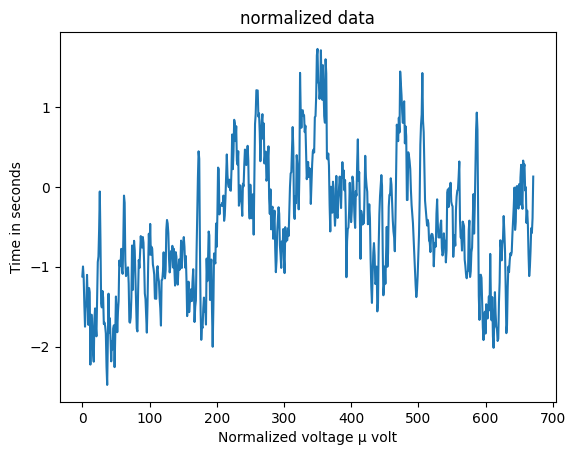

In [68]:
plt.plot(X[0][0][:3200])
plt.title("normalized data")
plt.xlabel("Normalized voltage µ volt")
plt.ylabel("Time in seconds")
plt.show()

# Visualization of treated data

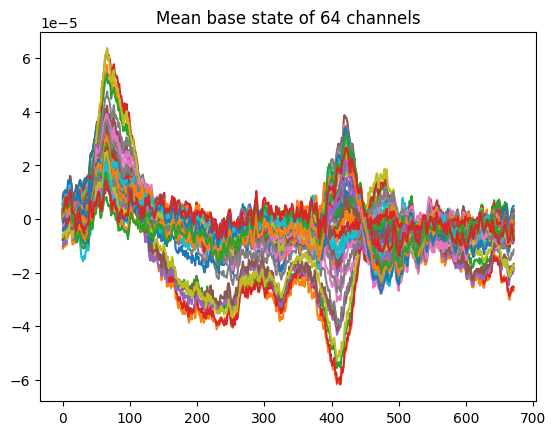

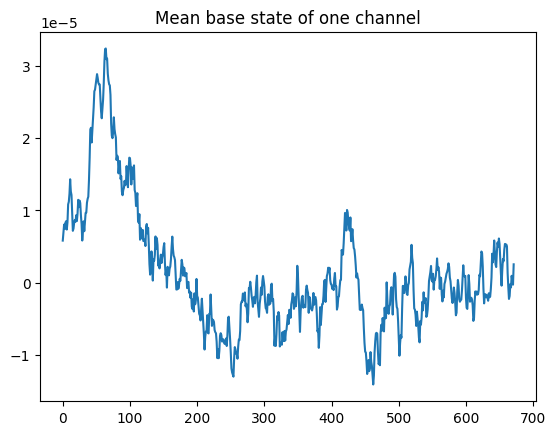

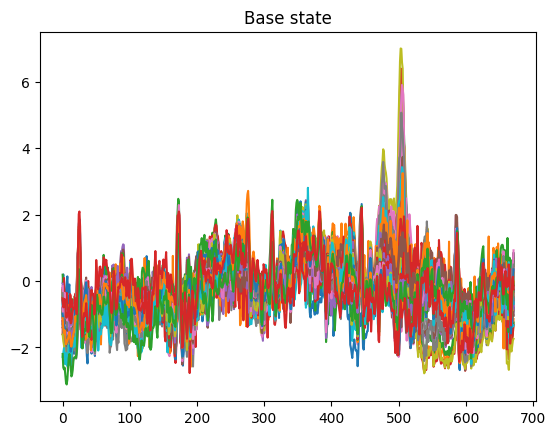

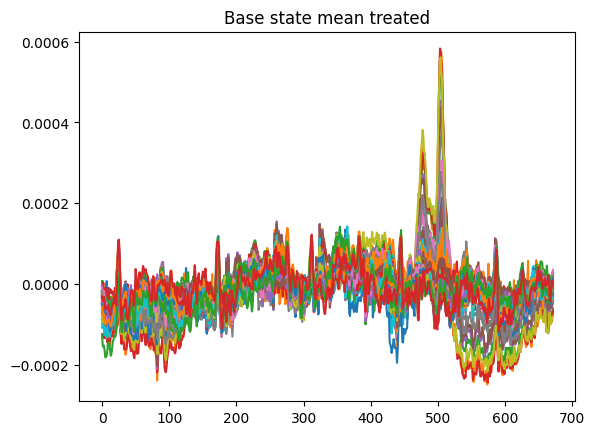

In [69]:
plt.plot(mean.T)
plt.title("Mean base state of 64 channels")
plt.show()
plt.plot(mean[1])
plt.title("Mean base state of one channel")
plt.show()
plt.plot(X[0].T)
plt.title("Base state")
plt.show()

plt.plot(X_t[0].T)
plt.title("Base state mean treated")
plt.show()


In [70]:
def split_and_convert(X,y,unsqueeze=False):
    X_train, X_temp, y_train, y_temp = train_test_split(
    X_t,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42)

    X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42)

    X_train=torch.tensor(X_train,dtype=torch.float32)
    y_train=torch.tensor(y_train,dtype=torch.long)

    X_val=torch.tensor(X_val,dtype=torch.float32)
    y_val=torch.tensor(y_val,dtype=torch.long)

    X_test=torch.tensor(X_test,dtype=torch.float32)
    y_test=torch.tensor(y_test,dtype=torch.long)
    if unsqueeze==True:
        X_train=X_train.unsqueeze(1)
        X_val=X_val.unsqueeze(1)
        X_test=X_test.unsqueeze(1)
    return X_train, y_train, X_val, y_val, X_test, y_test

In [71]:
#============== UNTREATED DATA
X_train_1D,y_train,X_val_1D,y_val,X_test_1D,y_test=split_and_convert(X,y)
#1D dataloaders
training_dataset_1D=TensorDataset(X_train_1D,y_train)
val_dataset_1D=TensorDataset(X_val_1D,y_val)
test_dataset_1D=TensorDataset(X_test_1D,y_test)
train_loader_1D = DataLoader(training_dataset_1D, batch_size=30, shuffle=True,generator=torch.Generator().manual_seed(42))
val_loader_1D = DataLoader(val_dataset_1D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))
test_loader_1D = DataLoader(test_dataset_1D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))

#2D dataloaders
X_train_2D,y_train,X_val_2D,y_val,X_test_2D,y_test=split_and_convert(X,y,True)
training_dataset_2D=TensorDataset(X_train_2D,y_train)
val_dataset_2D=TensorDataset(X_val_2D,y_val)
test_dataset_2D=TensorDataset(X_test_2D,y_test)
train_loader_2D = DataLoader(training_dataset_2D, batch_size=30, shuffle=True,generator=torch.Generator().manual_seed(42))
val_loader_2D = DataLoader(val_dataset_2D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))
test_loader_2D = DataLoader(test_dataset_2D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))

#============== TREATED DATA
#1D dataloaders
X_t_train_1D,y_train,X_t_val_1D,y_val,X_t_test_1D,y_test=split_and_convert(X_t,y)
training_dataset_t_1D=TensorDataset(X_t_train_1D,y_train)
val_dataset_t_1D=TensorDataset(X_t_val_1D,y_val)
test_dataset_t_1D=TensorDataset(X_t_test_1D,y_test)
train_loader_t_1D = DataLoader(training_dataset_t_1D, batch_size=30, shuffle=True,generator=torch.Generator().manual_seed(42))
val_loader_t_1D = DataLoader(val_dataset_t_1D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))
test_loader_t_1D = DataLoader(test_dataset_t_1D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))

#2D dataloaders
X_t_train_2D,y_train, X_t_val_2D,y_val,X_t_test_2D,y_test=split_and_convert(X_t,y,True)
training_dataset_t_2D=TensorDataset(X_t_train_2D,y_train)
val_dataset_t_2D=TensorDataset(X_t_val_2D,y_val)
test_dataset_t_2D=TensorDataset(X_t_test_2D,y_test)
train_loader_t_2D = DataLoader(training_dataset_t_2D, batch_size=30, shuffle=True,generator=torch.Generator().manual_seed(42))
val_loader_t_2D = DataLoader(val_dataset_t_2D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))
test_loader_t_2D = DataLoader(test_dataset_t_2D, batch_size=30, shuffle=False,generator=torch.Generator().manual_seed(42))


C:\Users\johan\AppData\Local\Temp\ipykernel_2128\2194703029.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  X_train=torch.tensor(X_train,dtype=torch.float32)


In [72]:
class eggNetWork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv2d= nn.Sequential(
            #block1
            nn.Conv2d(1,16,(1,40),padding=10),
            nn.BatchNorm2d(16),
            nn.ELU(),
            

            #block2
            nn.Conv2d(16,32,(64,3),padding=10),
            nn.BatchNorm2d(32),
            nn.ELU(),
           

            #block3
            nn.Conv2d(32,64,(20,20),padding=10),
            nn.ELU(),
            nn.BatchNorm2d(64),
            

            nn.AdaptiveAvgPool2d(2),
            nn.Flatten()  
        )

        self.conv1d= nn.Sequential(
            #block1
            nn.Conv1d(64,32,64,padding=10),
            nn.ELU(),
            nn.BatchNorm1d(32),

            #block2
            nn.Conv1d(32,16,40,padding=10),
            nn.ELU(),
            nn.BatchNorm1d(16),

            #block3
            nn.Conv1d(16,8,20,padding=10,stride=2),
            nn.ELU(),
            nn.BatchNorm1d(8), 


            nn.AdaptiveAvgPool1d(3),
            nn.Flatten()
        )

        self.fc=nn.Sequential(
            nn.Linear(64*2*2+24, 9)
        )

        

    def forward(self, x1d,x2d):
        con1d=self.conv1d(x1d)
        con2d=self.conv2d(x2d)
        x=torch.cat((con1d,con2d),dim=1)
        out=self.fc(x)
        return out


In [73]:
module=eggNetWork().to(device)
criterion=nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(module.parameters(), lr=0.005, momentum=0.9)


In [74]:
def training_and_evaluation(module ,device, opt, train_loader_1D,train_loader_2D,val_loader_1D,val_loader_2D):

    module.train()
    total_loss=0
    val_loss=0
    for (X1,y1),(X2,y2) in zip(train_loader_1D,train_loader_2D):
        X1, X2, y1, y2=X1.to(device), X2.to(device), y1.to(device), y2.to(device)
        optimizer.zero_grad() #rest the greadient
        
        pred=module(X1,X2) 
        loss=criterion(pred,y1)
        loss.backward()
        opt.step()
        avrg_batch_loss=loss.item()
        total_loss+=loss.item()
    
    print(f"total_loss: {total_loss}")

    module.eval()
    with torch.no_grad():
        print("evaluation")
        all_preds = []
        all_targets = []
        counter=0
        for (X1,y1),(X2,y2) in zip(val_loader_1D,val_loader_2D):
            X1, X2, y1, y2=X1.to(device), X2.to(device), y1.to(device), y2.to(device)
            pred=module(X1,X2)
            predicted = pred.argmax(dim=1)
            loss=criterion(pred,y1)
            
            val_loss+=loss.item()
            counter+=1
            all_preds.extend([int(v) for v in predicted])
            all_targets.extend([int(v) for v in y1])
        print(f"val_loss: {val_loss}")
        print("Target distribution:", Counter(all_targets))
        print("Prediction distribution:", Counter(all_preds))

    print("Finnished training")
        
        

In [20]:
def testing(module,device, test_loader_1D,test_loader_2D):
    module.eval()
    total_loss=0
    correct=0
    total=0
    with torch.no_grad():
        for (X1,y1),(X2,y2) in zip(test_loader_1D,test_loader_2D):
            X1, X2, y1, y2=X1.to(device), X2.to(device), y1.to(device), y2.to(device)
            pred=module(X1,X2)
            loss=criterion(pred,y1)
            total_loss+=loss.item()
            _,indices=torch.max(pred,1)
            correct+=(indices==y1).sum().item()
            total+=len(y1)
        print(100*(correct/total))

    

In [ ]:
training_and_evaluation(module=module,device=device,opt=optimizer ,train_loader_1D=train_loader_1D,train_loader_2D=train_loader_2D,val_loader_1D=val_loader_1D,val_loader_2D=val_loader_2D)

total_loss: 17.524612545967102
evaluation
val_loss: 4.11061429977417
Target distribution: Counter({0: 27, 3: 4, 1: 4, 8: 4, 4: 3, 7: 3, 6: 3, 2: 3, 5: 3})
Prediction distribution: Counter({0: 54})
Finnished training


: 

In [42]:
testing(module,device=device,test_loader_1D=test_loader_1D,test_loader_2D=test_loader_2D)

50.0
